In [1]:
import requests
import os
import inspect


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import cm

import umap, numpy as np, pandas as pd

from nltk import FreqDist

import pandas as pd
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 50)

from transformers import AutoModel, AutoTokenizer
from transformers import PreTrainedTokenizer

from sklearn.decomposition import TruncatedSVD
from scipy import sparse
import numpy as np

from collections import Counter
from scipy.sparse import csr_matrix

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold      import TSNE
import umap, numpy as np, pandas as pd, matplotlib.pyplot as plt


from tensor2tensor.data_generators import text_encoder
import importlib

/home/jupyter-vojta/notebooks/labyrinth/venv_torch_nlp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-28 15:32:56.048560: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-28 15:32:56.085348: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import warnings
warnings.filterwarnings('ignore')

# Or for specific warning types:
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
labyrinthus_df = pd.read_parquet("../data/large_files/labyrinthus_embeddings.parquet")
labyrinthus_df.sample(5)

,author,title,grela_id,sentence_id,sentence_text,context_3sents,tokens,concordance_tokens,not_before,not_after,date_random,lagt_genre,lagt_provenience,noscemus_genre,noscemus_discipline,target_token_id,target_char_start,target_char_end,concordance_tokens_str,classification_single,classification_single_label,xlmr_sentence,xlmr_sp_tokens,xlmr_aug_tokens,xlmr_conc_text,xlmr_conc_sp_tokens,xlmr_conc_aug_tokens,labert_sentence,labert_sp_tokens,labert_aug_tokens,labert_conc_text,labert_conc_sp_tokens,labert_conc_aug_tokens,cooc_vector,cooc_conc_vector,svd400,svd400_conc
778,"Borelli, Giovanni Alfonso",De motu animalium Ioannis Alphonsi Borelli Neapolitani matheseos professoris opus posthumum.,noscemus_808110,noscemus_808110_4901,"sed tortuoso uermiculari ad latera hinc inde, ante, & retro digrediendo, ad instar labyrinthi progrediuntur, & postea ambiunt substantiam testis;","Quia arteriae spermaticae paulo ante, & post ingressum in testes, non directo, & breuissimo cursu feruntur, ut solemne est in omnibus corporis partibus; | sed tortuoso uermiculari ad latera hinc i...","[{'char_end': 3, 'char_start': 0, 'lemma': 'sed', 'pos': 'CCONJ', 'sentence_id': 'noscemus_808110_4901', 'token_id': 101860355, 'token_text': 'sed'}, {'char_end': 12, 'char_start': 4, 'lemma': 'to...","[{'char_end': 44, 'char_start': 40, 'lemma': 'inde', 'pos': 'ADV', 'sentence_id': 'noscemus_808110_4901', 'token_id': 101860361, 'token_text': 'inde'}, {'char_end': 45, 'char_start': 44, 'lemma': ...",1680.0,1681.0,1680.0,None,None,"Monograph, Encyclopedic work","Mathematics, Physics, Biology",101860371,83,93,"inde , ante , & retro digrediendo , ad instar labyrinthi progrediuntur , & postea ambiunt substantiam testis ; Insuper omnia",4,medical_anatomical,"sed tortuoso uermiculari ad latera hinc inde , ante , & retro digrediendo , ad instar labyrinthus progrediuntur , & postea ambiunt substantiam testis ;","[<s>, ▁sed, ▁tortu, oso, ▁u, er, mi, cular, i, ▁ad, ▁later, a, ▁hinc, ▁inde, ▁, ,, ▁ante, ▁, ,, ▁&, ▁retro, ▁di, gredi, endo, ▁, ,, ▁ad, ▁in, star, ▁la, byr, int, hus, ▁pro, gredi, untur, ▁, ,, ▁&...","[{'char_end': 3, 'char_start': 0, 'lemma': 'sed', 'pos': 'CCONJ', 'sentence_id': 'noscemus_808110_4901', 'sp_first': 1, 'sp_pieces': ['▁sed'], 'token_id': 101860355, 'token_text': 'sed'}, {'char_e...","inde , ante , & retro digrediendo , ad instar labyrinthus progrediuntur , & postea ambiunt substantiam testis ; insuper omnia","[<s>, ▁inde, ▁, ,, ▁ante, ▁, ,, ▁&, ▁retro, ▁di, gredi, endo, ▁, ,, ▁ad, ▁in, star, ▁la, byr, int, hus, ▁pro, gredi, untur, ▁, ,, ▁&, ▁postea, ▁amb, i, unt, ▁sub, stant, iam, ▁testi, s, ▁;, ▁in, s...","[{'char_end': 44, 'char_start': 40, 'lemma': 'inde', 'pos': 'ADV', 'sentence_id': 'noscemus_808110_4901', 'sp_first': 1, 'sp_pieces': ['▁inde'], 'token_id': 101860361, 'token_text': 'inde'}, {'cha...","sed tortuoso uermiculari ad latera hinc inde , ante , & retro digrediendo , ad instar labyrinthus progrediuntur , & postea ambiunt substantiam testis ;","[<s>, sed_, tort, uos, o_, uer, micu, lari_, ad_, latera_, hinc_, inde_, ,_, ante_, ,_, &_, retro_, digre, dien, do_, ,_, ad_, instar_, lab, yri, nth, us_, progredi, untur_, ,_, &_, postea_, ambi,...","[{'char_end': 3, 'char_start': 0, 'lemma': 'sed', 'pos': 'CCONJ', 'sentence_id': 'noscemus_808110_4901', 'sp_first': 1, 'sp_pieces': ['sed_'], 'token_id': 101860355, 'token_text': 'sed'}, {'char_e...","inde , ante , & retro digrediendo , ad instar labyrinthus progrediuntur , & postea ambiunt substantiam testis ; insuper omnia","[<s>, inde_, ,_, ante_, ,_, &_, retro_, digre, dien, do_, ,_, ad_, instar_, lab, yri, nth, us_, progredi, untur_, ,_, &_, postea_, ambi, unt_, substantiam_, testis_, ;_, insuper_, omnia_, </s>]","[{'char_end': 44, 'char_start': 40, 'lemma': 'inde', 'pos': 'ADV', 'sentence_id': 'noscemus_808110_4901', 'sp_first': 1, 'sp_pieces': ['inde_'], 'token_id': 101860361, 'token_text': 'inde'}, {'cha...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

## Simple classification check

In [4]:
# ------------------------------------------------------------------
# common objects
# ------------------------------------------------------------------
y = labyrinthus_df["classification_single_label"].values  # 21 classes incl. “other”
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# basic experiments with contextual embeddings

lr = LogisticRegression(
    max_iter=4000,
    solver="lbfgs",
    n_jobs=-1)

rf = RandomForestClassifier(
    n_estimators=200,  # more trees for stability
    max_depth=None,  # let it grow fully
    n_jobs=-1,  # parallelizex
    random_state=42)

hgbc = HistGradientBoostingClassifier(
    random_state=42)

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(512, 128),
                    activation='relu',
                    solver='adam',
                    alpha=1e-4,
                    max_iter=500,
                    random_state=42)

clfs = {"lr" : lr, "rf" : rf, "hgbc" : hgbc, "mlp" : mlp}

In [5]:
def load_embedding(name, base_dir="../data/labyrinth_embeddings"):
    return np.load(f"{base_dir}/{name}.npy", mmap_mode="r")

In [15]:
emb_col = "att_conc_l8_xlmr_raw_embed"
X = np.stack(load_embedding(emb_col))
y_pred = cross_val_predict(rf, X, y, cv=cv)
acc = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred, average="macro")
f1

0.5485859704263075

In [16]:
emb_col = "embed_conc_l8_xlmr"
X = np.stack(load_embedding(emb_col))
y_pred = cross_val_predict(lr, X, y, cv=cv)
acc = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred, average="macro")
f1

0.601754552014326

In [17]:
X_scaled = StandardScaler().fit_transform(X)

In [19]:
emb_col = "embed_l11_xlmr"
X = np.stack(load_embedding(emb_col))
cv = StratifiedKFold(n_splits=5, shuffle=True)
y_pred = cross_val_predict(mlp, X, y, cv=cv)
acc = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred, average="macro")
f1

0.6203693559659021

In [31]:
emb_col = "embed_l11_labert_wsd"
X = np.stack(load_embedding(emb_col))
cv = StratifiedKFold(n_splits=5, shuffle=True)
y_pred = cross_val_predict(mlp, X, y, cv=cv)
acc = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred, average="macro")
f1

0.5965739015193277

Min: 0
Max: 14
Mean: 6.74235807860262
Median: 7.0
Std: 2.456431827175624


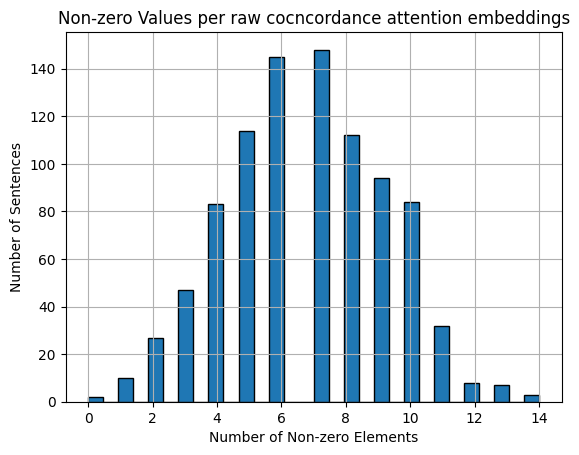

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Stack the embeddings into a 2D numpy array
emb_col = "att_conc_l11_xlmr_raw_embed"
X = np.stack(load_embedding(emb_col))

# Count number of non-zero entries in each row
non_zero_counts = np.count_nonzero(X, axis=1)

# Print basic stats
print("Min:", non_zero_counts.min())
print("Max:", non_zero_counts.max())
print("Mean:", non_zero_counts.mean())
print("Median:", np.median(non_zero_counts))
print("Std:", non_zero_counts.std())

# Plot histogram
plt.hist(non_zero_counts, bins=30, edgecolor='black')
plt.title("Non-zero Values per raw cocncordance attention embeddings")
plt.xlabel("Number of Non-zero Elements")
plt.ylabel("Number of Sentences")
plt.grid(True)
plt.show()

## Projections

In [6]:
# ─────────────────────────── reductions dict (unchanged) ──────────────────────────

REDUCTIONS = {
    # --- UMAP variants ---
    "umap_10_0.05": lambda: umap.UMAP(n_neighbors=10,  min_dist=0.05,
                                      metric="cosine", random_state=42),
    "umap_50_0.5" : lambda: umap.UMAP(n_neighbors=50,  min_dist=0.5 ,
                                      metric="cosine", random_state=42),
    "umap_100_0.8": lambda: umap.UMAP(n_neighbors=100, min_dist=0.8,
                                      metric="cosine", random_state=42),
    # --- t-SNE variants ---
    "tsne_10": lambda: TSNE(n_components=2, perplexity=10,
                            metric="cosine", init="pca",
                            learning_rate=200, random_state=42),
    "tsne_30": lambda: TSNE(n_components=2, perplexity=30,
                            metric="cosine", init="pca",
                            learning_rate=200, random_state=42),
    "tsne_50": lambda: TSNE(n_components=2, perplexity=50,
                            metric="cosine", init="pca",
                            learning_rate=200, random_state=42),
    # --- PCA variants ---
    "pca_std"   : lambda: PCA(n_components=2, whiten=False , random_state=42),
    "pca_whiten": lambda: PCA(n_components=2, whiten=True  , random_state=42),
    # --- PCA→t-SNE speed trick ---
    "pca10_tsne": lambda: (
        lambda X: TSNE(n_components=2, perplexity=30,
                       init="pca", random_state=42)
                  .fit_transform(PCA(n_components=10, random_state=42)
                                 .fit_transform(X))
    )
}
# ────────────────────────────────────────────────────────────────────────────────

def compute_projections(embeddings: np.ndarray,
                        reductions: dict[str, callable] = REDUCTIONS) -> pd.Series:
    """
    embeddings : np.ndarray  shape (N, dim)
    returns    : pd.Series  length N, each cell = {proj_name: {"x": …,"y": …}, …}
    """
    X = np.asarray(embeddings)
    coords = {}

    for name, maker in reductions.items():
        reducer = maker()
        if hasattr(reducer, "fit_transform"):
            coords[name] = reducer.fit_transform(X)
        else:                      # callable expecting X directly (pca10_tsne)
            coords[name] = reducer(X)

    def row_dict(i):
        return {n: {"x": float(coords[n][i, 0]), "y": float(coords[n][i, 1])}
                for n in coords}

    return pd.Series([row_dict(i) for i in range(len(X))])


In [7]:
# unique_lbls = sorted(labyrinthus_df["classification_single_label"].unique())
unique_lbls = ["mythological",
    "technical_literal",
    "confusion_metaphorics",
    "scientific_complexity_metaphorics",
    "medical_anatomical",
    "ambiguous_indeterminate"]


N = len(unique_lbls)
# Pick a discrete palette, extend if labels > 20
#cmap_name = "tab20" if N > 10 else "tab10"
#cmap = cm.get_cmap(cmap_name, N)
#palette = {
#    lbl: cmap(i)
#    for i, lbl in enumerate(unique_lbls)
#}

In [8]:
palette = {
    "mythological": "#1E40AF", # "#7D3FB2",  # Regal violet — imaginative, mythic depth
    "technical_literal": "#7D3FB2", # "#C68E17",  # Golden ochre — tangible, crafted, architectural
    "confusion_metaphorics":  "#228B68",  # Emerald teal — organic, physiological clarity
    "scientific_complexity_metaphorics": "#C68E17", #"#1E40AF",  # Deep royal blue — intellectual, analytical
    "medical_anatomical": "#C24130",  # Burnt orange-red — emotional, human, entangled
    "ambiguous_indeterminate": "#6B7280",  # Neutral slate gray — uncertain, indeterminate
}  #

In [20]:

# ---# ---------------------------------------------------------------
# 3)  Plot function with coloured dots
# ------------------------------------------------------------------


def plot_projections(title, projections: pd.Series,
                     labels: pd.Series,
                     palette: dict,
                     show: bool = True) -> plt.Figure:
    PROJECTION_GROUPS = {
        "UMAP":  ["umap_10_0.05", "umap_50_0.5", "umap_100_0.8"],
        "t-SNE": ["tsne_10",      "tsne_30",     "tsne_50"],
        "PCA":   ["pca_std",      "pca_whiten",  "pca10_tsne"],
    }

    fig, axes = plt.subplots(3, 3, figsize=(13, 13))
    fig.suptitle("2-D projections of {} embeddings".format(title), fontsize=16)

    for row_idx, (tech, keys) in enumerate(PROJECTION_GROUPS.items()):
        for col_idx, key in enumerate(keys):
            ax = axes[row_idx, col_idx]

            xs = projections.apply(lambda d: d[key]["x"])
            ys = projections.apply(lambda d: d[key]["y"])
            cols = labels.map(palette)

            ax.scatter(xs, ys, c=cols, s=8, alpha=0.6)
            ax.set_title(f"{tech} — {key}", fontsize=9)
            ax.axis("off")

    # add a compact legend outside the grid
    handles = [plt.Line2D([0], [0], marker='o', linestyle='',
                          color=palette[l], label=l, markersize=6)
               for l in labels.unique()]
    legend = fig.legend(handles=handles, ncol=min(5, len(handles)),
                    bbox_to_anchor=(0.5, -0.02), loc="upper center")

    plt.tight_layout(rect=[0, 0.02, 1, 0.95])

    if not show:
        plt.close(fig)  # Suppress automatic display in Jupyter

    return fig

In [16]:
labyrinthus_df["classification_single_label"].value_counts()

classification_single_label
scientific_complexity_metaphorics    270
confusion_metaphorics                249
medical_anatomical                   193
technical_literal                     91
ambiguous_indeterminate               65
mythological                          48
Name: count, dtype: int64

In [21]:
def plot_projections_for_embeddings(emb_array, title, show=True):
    proj_series = compute_projections(emb_array)
    fig = plot_projections(title,
                       proj_series,
                       labyrinthus_df["classification_single_label"],
                       palette, show)
    return fig

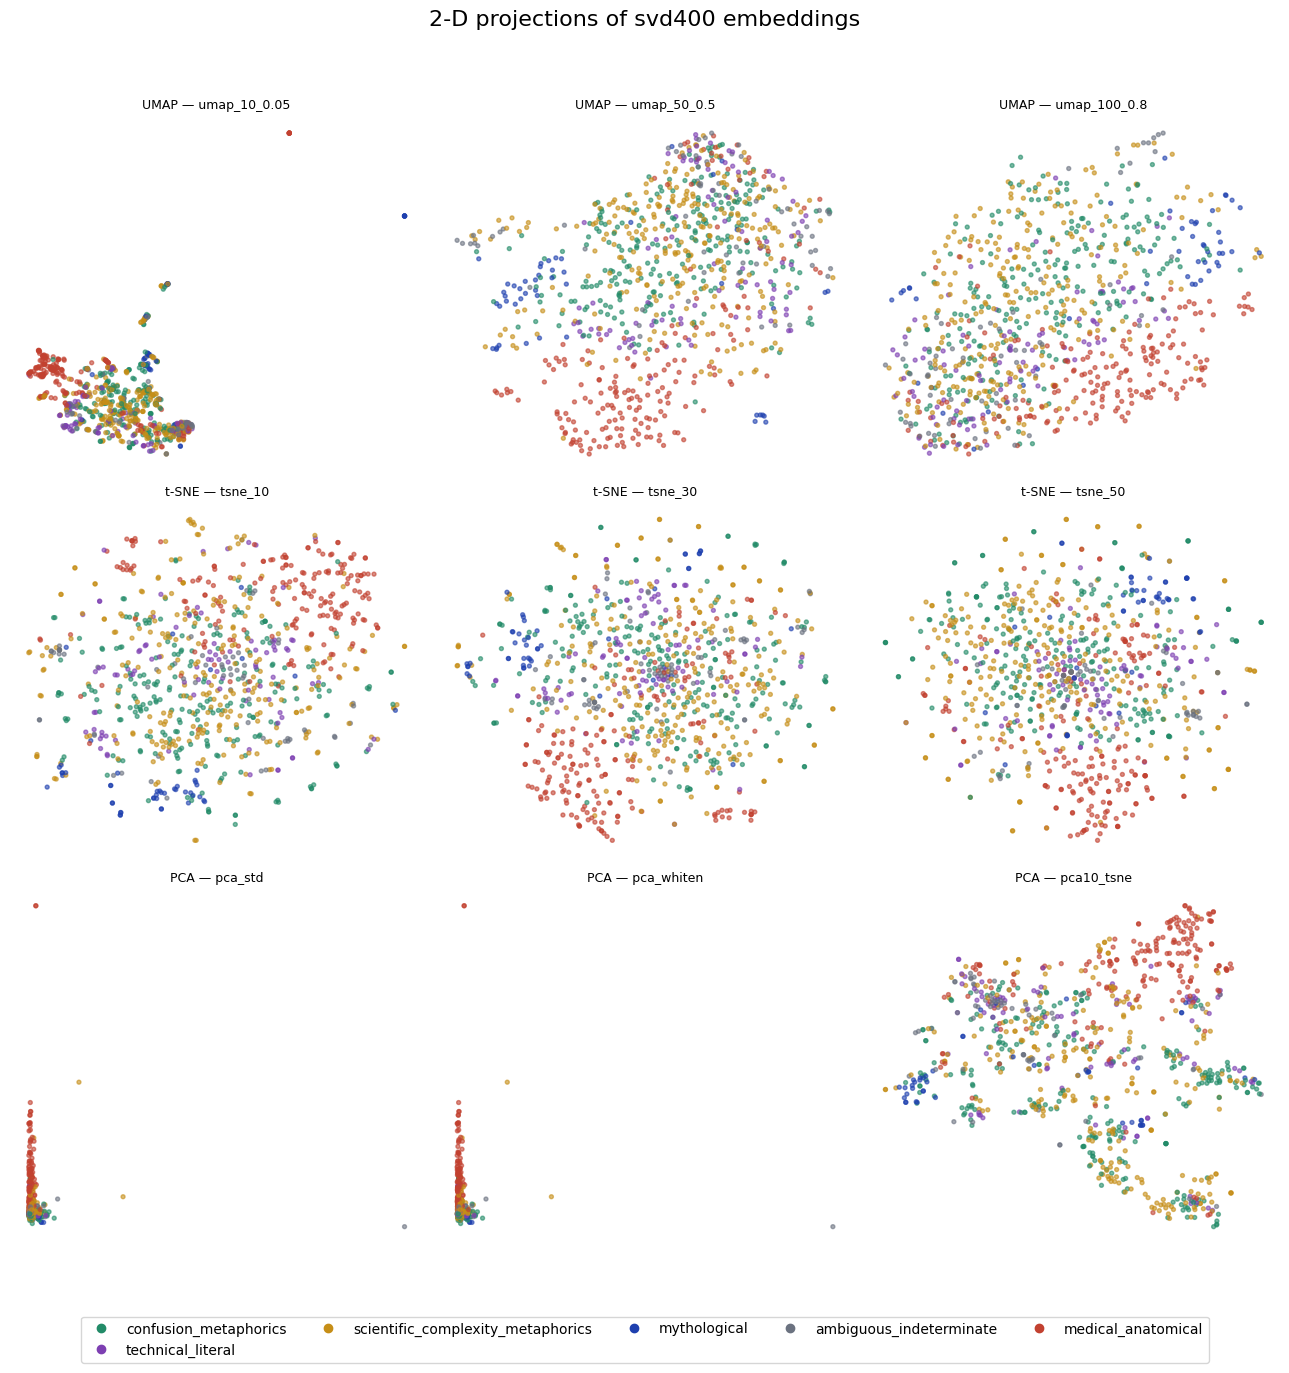

In [28]:
emb = "svd400"
emb_array = np.stack(load_embedding(emb))
fig = plot_projections_for_embeddings(emb_array, emb)

In [29]:
fig.savefig("../figures/labyrinthus_projections_svd400.png",
            dpi=300, bbox_inches="tight")

In [ ]:
emb_col = "att_l9_xlmr_svd400_embed"
emb_array = np.stack(load_embedding(emb_col))
fig = plot_projections_for_embeddings(emb_array, "att_l9_xlmr_svd400_embed")

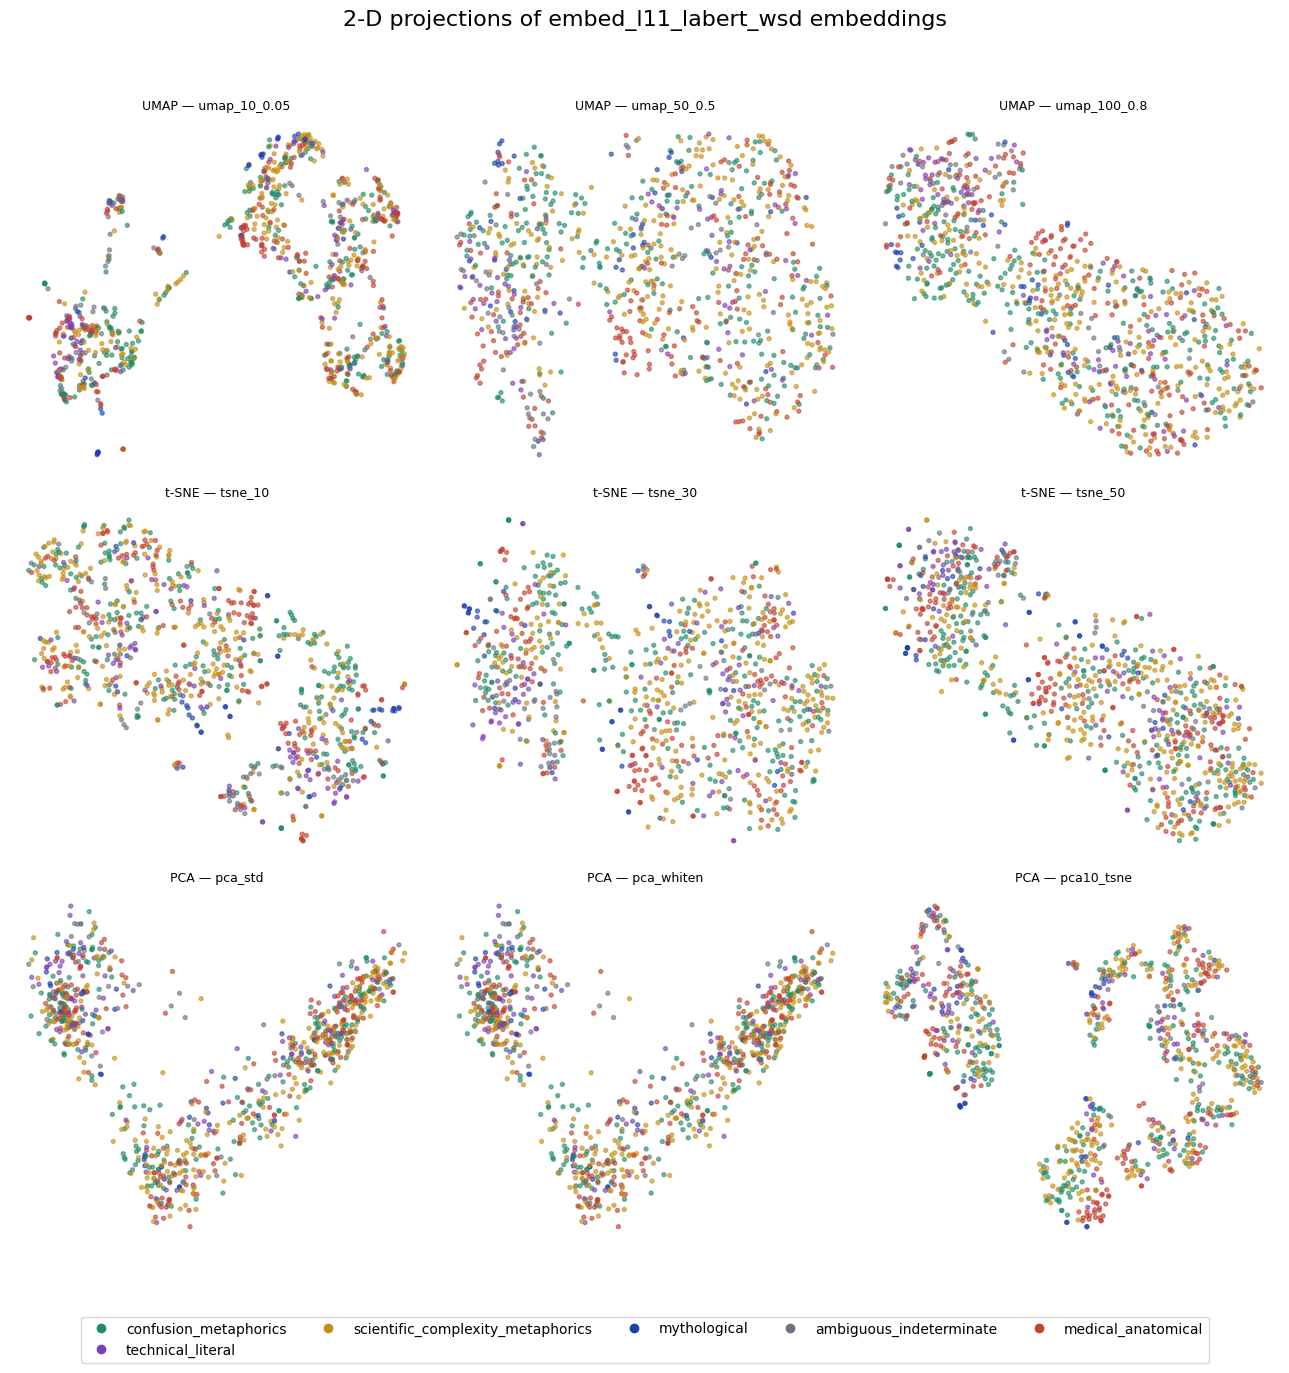

In [46]:
emb_col = "embed_l11_labert_wsd"
emb_array = np.stack(load_embedding(emb_col))
fig = plot_projections_for_embeddings(emb_array, "embed_l11_labert_wsd")

In [47]:
fig.savefig("../figures/labyrinthus_projections_embed_l11_labert_wsd.png", dpi=300)

In [25]:
def merge_embeddings(embs, method="concat") -> np.ndarray:
    loaded_embs = [load_embedding(e) for e in embs]
    if method == "concat":
        embeddings_merged = np.concatenate(loaded_embs, axis=1)
    if method == "mean":
        try:
            embeddings_merged = np.mean(loaded_embs, axis=1)
        except:
            print(f"mean not possible, defaulting to concat")
            embeddings_merged = np.concatenate(loaded_embs, axis=1)
    return embeddings_merged

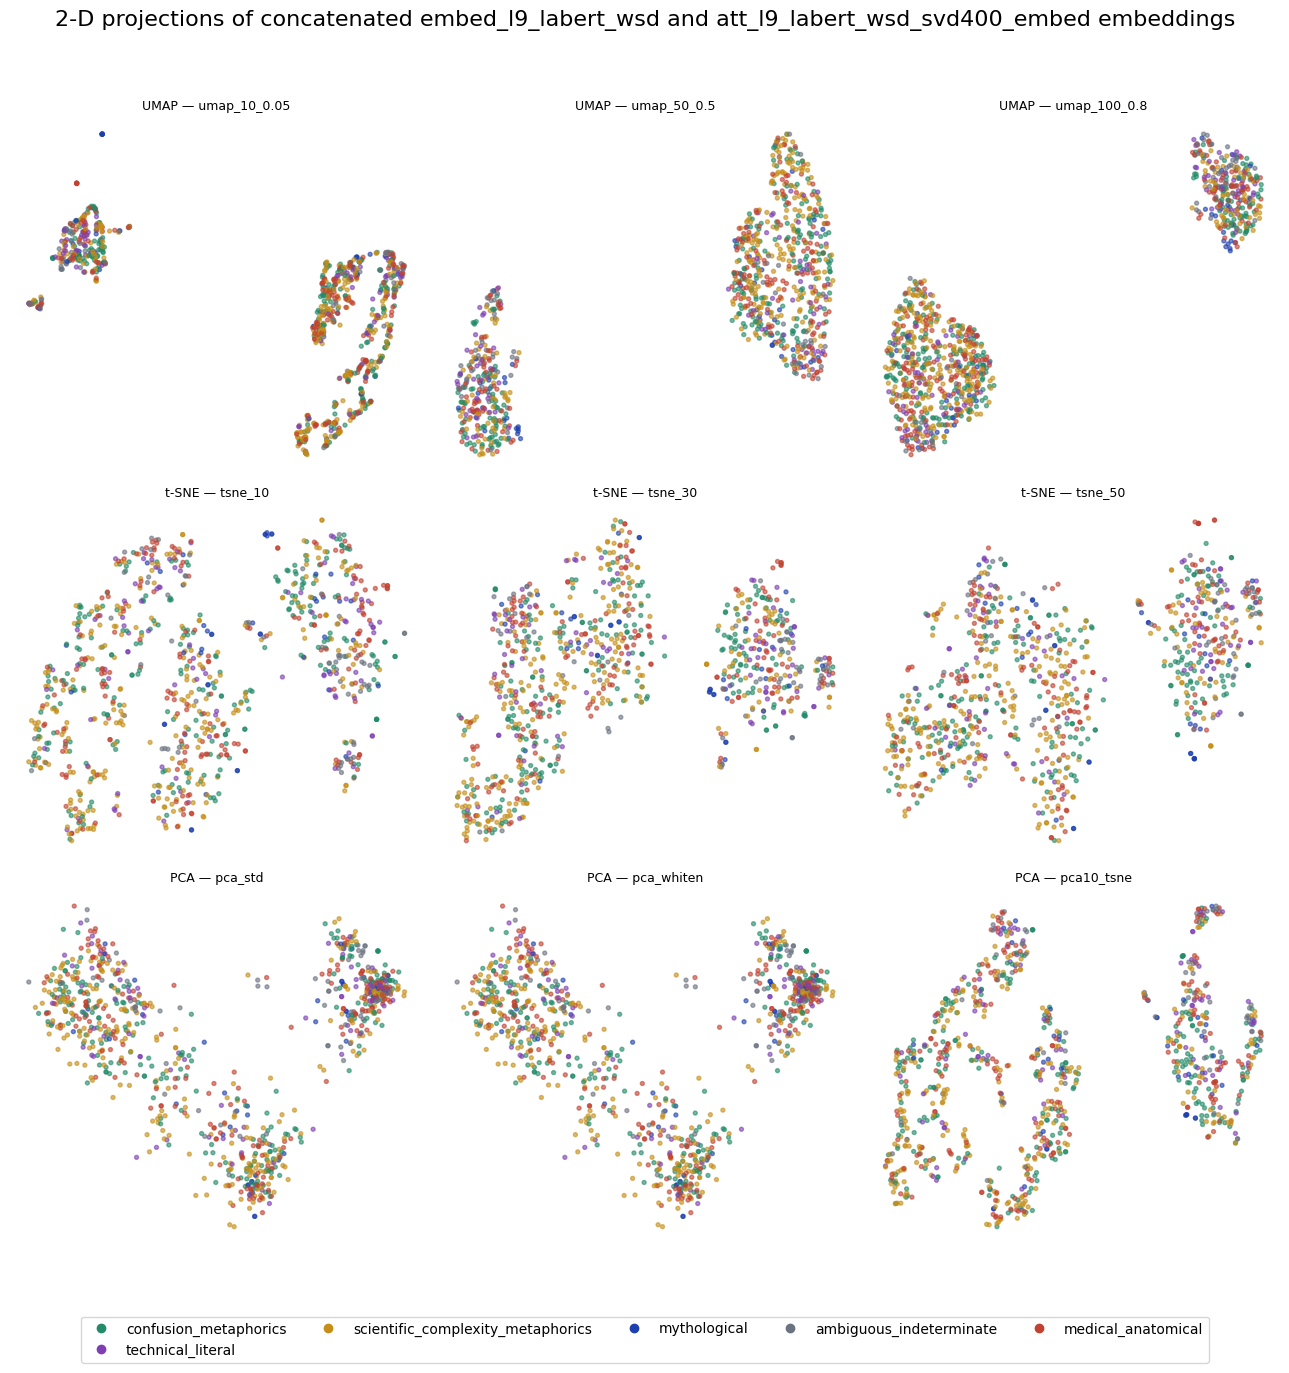

In [31]:
emb_array = merge_embeddings(["embed_l9_labert_wsd", "att_l9_labert_wsd_svd400_embed"])
fig = plot_projections_for_embeddings(emb_array, "concatenated embed_l9_labert_wsd and att_l9_labert_wsd_svd400_embed")

In [32]:
fig.savefig("../figures/labyrinthus_projections_labert_wsd_embed_l9_labert_wsd_AND_att_l9_labert_wsd_svd400_embed.png",
            dpi=300, bbox_inches="tight")

In [91]:
labyrinthus_df.columns.tolist()

In [50]:
embeddings_unsorted = ['embed_l7_xlmr',
 'embed_conc_l7_xlmr',
 'embed_l8_xlmr',
 'embed_conc_l8_xlmr',
 'embed_l9_xlmr',
 'embed_conc_l9_xlmr',
 'embed_l10_xlmr',
 'embed_conc_l10_xlmr',
 'embed_l11_xlmr',
 'embed_conc_l11_xlmr',
 'embed_l7_labert',
 'embed_conc_l7_labert',
 'embed_l8_labert',
 'embed_conc_l8_labert',
 'embed_l9_labert',
 'embed_conc_l9_labert',
 'embed_l10_labert',
 'embed_conc_l10_labert',
 'embed_l11_labert',
 'embed_conc_l11_labert',
 'att_l7_xlmr_svd400_embed',
 'att_l8_xlmr_svd400_embed',
 'att_l9_xlmr_svd400_embed',
 'att_l10_xlmr_svd400_embed',
 'att_l11_xlmr_svd400_embed',
 'att_conc_l7_xlmr_svd400_embed',
 'att_conc_l8_xlmr_svd400_embed',
 'att_conc_l9_xlmr_svd400_embed',
 'att_conc_l10_xlmr_svd400_embed',
 'att_conc_l11_xlmr_svd400_embed',
 'att_l7_labert_svd400_embed',
 'att_l8_labert_svd400_embed',
 'att_l9_labert_svd400_embed',
 'att_l10_labert_svd400_embed',
 'att_l11_labert_svd400_embed',
 'att_conc_l7_labert_svd400_embed',
 'att_conc_l8_labert_svd400_embed',
 'att_conc_l9_labert_svd400_embed',
 'att_conc_l10_labert_svd400_embed',
 'att_conc_l11_labert_svd400_embed',
 'svd400',
 'svd400_conc']

In [12]:
xlmr_sentence_contextual_embeddings = [
    'embed_l7_xlmr', 'embed_l8_xlmr', 'embed_l9_xlmr',
    'embed_l10_xlmr', 'embed_l11_xlmr'
]

xlmr_concordance_contextual_embeddings = [
    'embed_conc_l7_xlmr', 'embed_conc_l8_xlmr', 'embed_conc_l9_xlmr',
    'embed_conc_l10_xlmr', 'embed_conc_l11_xlmr'
]

xlmr_sentence_attention_embeddings = [
    'att_l7_xlmr_svd400_embed', 'att_l8_xlmr_svd400_embed',
    'att_l9_xlmr_svd400_embed', 'att_l10_xlmr_svd400_embed',
    'att_l11_xlmr_svd400_embed'
]

xlmr_concordance_attention_embeddings = [
    'att_conc_l7_xlmr_svd400_embed', 'att_conc_l8_xlmr_svd400_embed',
    'att_conc_l9_xlmr_svd400_embed', 'att_conc_l10_xlmr_svd400_embed',
    'att_conc_l11_xlmr_svd400_embed'
]
labert_sentence_contextual_embeddings = [
    'embed_l7_labert', 'embed_l8_labert', 'embed_l9_labert',
    'embed_l10_labert', 'embed_l11_labert'
]

labert_concordance_contextual_embeddings = [
    'embed_conc_l7_labert', 'embed_conc_l8_labert', 'embed_conc_l9_labert',
    'embed_conc_l10_labert', 'embed_conc_l11_labert'
]

labert_sentence_attention_embeddings = [
    'att_l7_labert_svd400_embed', 'att_l8_labert_svd400_embed',
    'att_l9_labert_svd400_embed', 'att_l10_labert_svd400_embed',
    'att_l11_labert_svd400_embed'
]

labert_concordance_attention_embeddings = [
    'att_conc_l7_labert_svd400_embed', 'att_conc_l8_labert_svd400_embed',
    'att_conc_l9_labert_svd400_embed', 'att_conc_l10_labert_svd400_embed',
    'att_conc_l11_labert_svd400_embed'
]

baseline_embeddings = ['svd400', 'svd400_conc']

In [35]:
for fn in os.listdir("../data/labyrinth_embeddings"):
    if "npy" in fn:
        emb_col = fn.split(".")[0]
        emb_array = np.stack(load_embedding(emb_col))
        fig = plot_projections_for_embeddings(emb_array, emb_col, show=False)
        fig.savefig(f"../figures/labyrinthus_projections_{emb_col}.png", dpi=300, bbox_inches="tight")

In [36]:
model = "labert_wsd"
for context in ["sentence", "concordance"]:
        for L in range(9, 12):
            if context == "sentence":
                emb1 = f"embed_l{L}_{model}"
                emb2 = f"att_l{L}_{model}_svd400_embed"
            else:
                emb1 = f"embed_conc_l{L}_{model}"
                emb2 = f"att_conc_l{L}_{model}_svd400_embed"
            emb_array = merge_embeddings([emb1, emb2], method="concat")
            fig = plot_projections_for_embeddings(emb_array, f"concatenated {emb1} & {emb2}", show=False)
            safe_name = f"{emb1}_AND_{emb2}".replace("/", "_")
            fig.savefig(f"../figures/labyrinthus_projections_{model}_{safe_name}.png", dpi=300, bbox_inches="tight")

In [37]:
for model in ["xlmr", "labert"]:
    for context in ["sentence", "concordance"]:
        for L in range(7, 12):
            if context == "sentence":
                emb1 = f"embed_l{L}_{model}"
                emb2 = f"att_l{L}_{model}_svd400_embed"
            else:
                emb1 = f"embed_conc_l{L}_{model}"
                emb2 = f"att_conc_l{L}_{model}_svd400_embed"
            emb_array = merge_embeddings([emb1, emb2], method="concat")
            fig = plot_projections_for_embeddings(emb_array, f"concatenated {emb1} & {emb2}", show=False)
            safe_name = f"{emb1}_AND_{emb2}".replace("/", "_")
            fig.savefig(f"../figures/labyrinthus_projections_{model}_{safe_name}.png", dpi=300, bbox_inches="tight")

In [17]:
#labyrinthus_df.to_parquet("../data/large_files/labyrinthus_embeddings.parquet")

## Supervised classification